In [51]:
import numpy as np
import pandas as pd
import json
import joblib
import os
import pickle
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

In [52]:
df = pd.read_csv("../data/processed/clean_data.csv")

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean'], df['label'], test_size=0.2, random_state=42
)

In [54]:
vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1,2))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

log_model = LogisticRegression(max_iter=3000)
log_model.fit(X_train_tfidf, y_train)

y_pred = log_model.predict(X_test_tfidf)

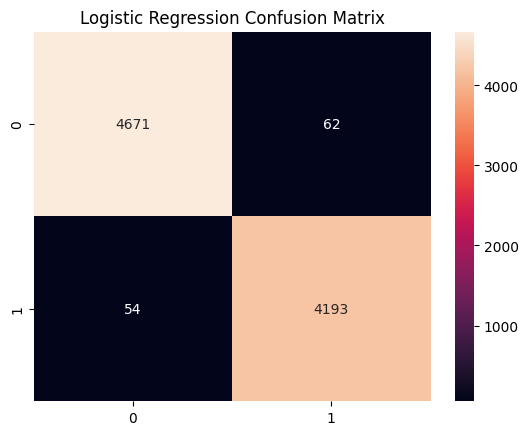

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4733
           1       0.99      0.99      0.99      4247

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [55]:
log_report = classification_report(y_test, y_pred, output_dict=True)
log_cm = confusion_matrix(y_test, y_pred)

with open("../outputs/results/log_metrics.json", "w") as f:
    json.dump(log_report, f, indent=4)

sns.heatmap(log_cm, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))

In [56]:
joblib.dump(log_model, "../outputs/models/log_model.pkl")
joblib.dump(vectorizer, "../outputs/models/vectorizer.pkl")

['../outputs/models/vectorizer.pkl']

In [57]:
def explain(text):
    vec = vectorizer.transform([text])
    pred = log_model.predict(vec)[0]

    names = vectorizer.get_feature_names_out()
    coefs = log_model.coef_[0]

    idx = vec.nonzero()[1]

    scores = [(names[i], coefs[i] * vec[0, i]) for i in idx]
    scores = sorted(scores, key=lambda x: abs(x[1]), reverse=True)[:5]

    print("Prediction:", "Real" if pred == 1 else "Fake")
    print("Reason:", [w for w, _ in scores])

In [58]:
explain(X_test.iloc[0])

Prediction: Fake
Reason: ['stein', 'court', 'trump', 'president trump', 'washington']


In [59]:
from collections import Counter

def build_vocab(texts, max_size: int = 10_000, min_freq: int = 2) -> dict:
    
    from collections import Counter
 
    counter = Counter()
    for text in texts:
        counter.update(text.split())
 
    vocab = {"<PAD>": 0, "<UNK>": 1}
    # Filter by frequency FIRST, then apply size cap
    frequent_words = [w for w, f in counter.most_common() if f >= min_freq]
    for word in frequent_words[: max_size - 2]:          # -2 for PAD + UNK
        vocab[word] = len(vocab)
 
    return vocab
 

In [60]:
vocab = build_vocab(X_train)

os.makedirs("../outputs/models", exist_ok=True)

with open("../outputs/models/vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)

print("Vocab saved ✔")

Vocab saved ✔


In [61]:
def to_seq(texts, vocab: dict, max_len: int = 200) -> np.ndarray:
    result = []
    for text in texts:
        seq = [vocab.get(w, 1) for w in text.split()]   # 1 = <UNK>
        seq = seq[:max_len] + [0] * (max_len - len(seq))
        result.append(seq)
    return np.array(result)

In [62]:
class LSTMModel(nn.Module):
 
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int = 128,
        hidden_dim: int = 128,
        n_layers: int = 2,
        dropout: float = 0.3,
    ):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)  # padding_idx added
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=n_layers,
            dropout=dropout,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_dim, 1)
 
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.emb(x)
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMModel(len(vocab) + 1).to(device)

X_train_t = torch.tensor(X_train_seq)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32)

loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_train_t, y_train_t),
    batch_size=32,
    shuffle=True
)

loss_fn = nn.BCEWithLogitsLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        opt.zero_grad()
        out = model(x).squeeze()
        loss = loss_fn(out, y)

        loss.backward()
        opt.step()

        total += loss.item()

    print("Epoch", epoch + 1, "Loss:", total / len(loader))

Epoch 1 Loss: 0.6398110486573655
Epoch 2 Loss: 0.4445806716901324
Epoch 3 Loss: 0.3573454141762781
Epoch 4 Loss: 0.1160555589307209
Epoch 5 Loss: 0.08216156440584664


In [64]:
model.eval()

X_test_t = torch.tensor(X_test_seq).to(device)

with torch.no_grad():
    logits = model(X_test_t).squeeze()
    preds = torch.sigmoid(logits).cpu().numpy()

y_pred_lstm = (preds > 0.5).astype(int)

lstm_report = classification_report(y_test, y_pred_lstm, output_dict=True)
lstm_cm = confusion_matrix(y_test, y_pred_lstm)

with open("../outputs/results/lstm_metrics.json", "w") as f:
    json.dump(lstm_report, f, indent=4)

torch.save(model.state_dict(), "../outputs/models/lstm_model.pth")

print(classification_report(y_test, y_pred_lstm))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97      4733
           1       0.99      0.93      0.96      4247

    accuracy                           0.96      8980
   macro avg       0.97      0.96      0.96      8980
weighted avg       0.96      0.96      0.96      8980



In [65]:
all_results = {
    "logistic_regression": log_report,
    "lstm": lstm_report
}

with open("../outputs/results/all_metrics.json", "w") as f:
    json.dump(all_results, f, indent=4)

print("All results saved ✔")

All results saved ✔


In [66]:
log_acc = log_report["accuracy"]
lstm_acc = lstm_report["accuracy"]

print("Logistic:", log_acc)
print("LSTM:", lstm_acc)

if lstm_acc > log_acc:
    print("LSTM wins (context aware model)")
else:
    print("Logistic wins (better for this dataset)")

Logistic: 0.9870824053452116
LSTM: 0.9631403118040089
Logistic wins (better for this dataset)


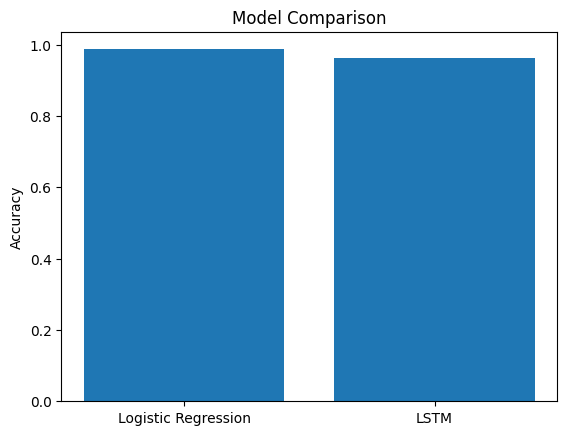

In [67]:
models = ["Logistic Regression", "LSTM"]
acc = [log_acc, lstm_acc]

plt.bar(models, acc)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()